In [142]:
# Problem 1. Sklearn vs Manual Least-Squares Calculation (Compulsory)

In [143]:
import pandas as pd
import numpy as np

In [144]:
df = pd.read_csv("AdvertisingData.csv", index_col=0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [145]:
x = df['TV'].to_numpy().reshape(-1,1)
y = df['sales'].to_numpy()

print(x.shape)

(200, 1)


In [146]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [147]:
β0 = model.intercept_
β1 = model.coef_[0]

# y = β0 + β1x
print("sklearn intercept β0:", β0)
print("sklearn slope β1:", β1)
print(f"Regression line: y_hat = {β0:.4f} + {β1:.4f} * TV")

sklearn intercept β0: 7.032593549127695
sklearn slope β1: 0.04753664043301975
Regression line: y_hat = 7.0326 + 0.0475 * TV


In [148]:
# flatten x into 1-D so it has the same dim as y for correct computations
x_ld = x.flatten()

x_mean = x_ld.mean()
y_mean = y.mean()

numerator = ((x_ld - x_mean) * (y - y_mean)).sum()
denominator = ((x_ld - x_mean)**2).sum()

# Calculate fit_β1
fit_β1 = numerator / denominator

# Calculate fit_β0
fit_β0 = y_mean - fit_β1 * x_mean

print("Intercept β0 = ", fit_β0)
print("Slope β1 = ", fit_β1)

print(f"Regression line: y_hat = {fit_β0:.4f} + {fit_β1:.4f} * TV")

Intercept β0 =  7.0325935491276965
Slope β1 =  0.047536640433019736
Regression line: y_hat = 7.0326 + 0.0475 * TV


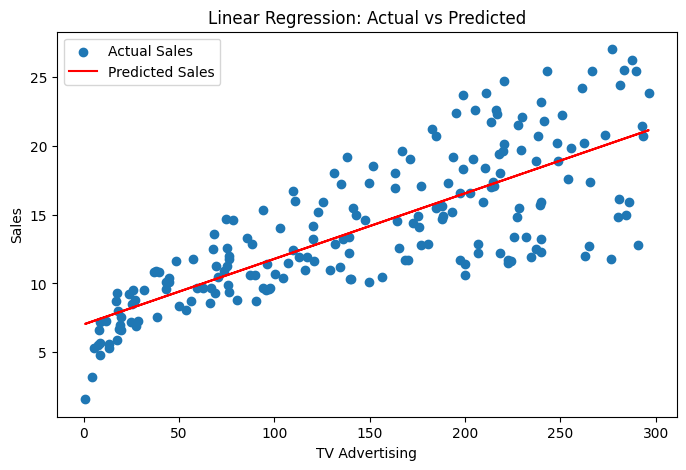

In [149]:
import matplotlib.pyplot as plt

# sklearn预测
y_pred = model.predict(x)


plt.figure(figsize=(8, 5))

# 真实数据
plt.scatter(df["TV"], y, label="Actual Sales")

# 预测回归线
plt.plot(df["TV"], y_pred, label="Predicted Sales", c='red')


plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.title("Linear Regression: Actual vs Predicted")

plt.legend()

plt.show()

In [150]:
# Problem 2. Calculate Standard Error, t-statistic and p-value for b1 (Optional)

In [151]:
# 计算预测值
y_pred = model.predict(x)

# 计算 residual 残差
residuals = y - y_pred

# 计算 RSS
RSS = np.sum(residuals ** 2)

# 计算 RSE
n = len(y)
RSE = np.sqrt(RSS / (n-2))

# 计算 slopeβ1 和 inercptβ0
x = df['TV']      
SE_beta1 = RSE / np.sqrt(np.sum( (x - x.mean())** 2 ) )
SE_beta0 = RSE * np.sqrt(1/n + x.mean()**2 / np.sum((x-x.mean())**2)) 

# 计算 t-statistic
beta0 = model.intercept_
beta1 = model.coef_[0]

t_value = beta1 / SE_beta1

# 计算 p-value
from scipy.stats import t
p_value = 2 * (1 - t.cdf(abs(t_value), df=n-2))

In [152]:
print("RSS:", RSS)
print("RSE:", RSE)
print("SE(beta0):", SE_beta0)
print("SE(beta1):", SE_beta1)
print(f"Regression line: y_hat = {beta0:.4f} + {beta1:.4f} * TV")
print("t:", t_value)
print("p-value:", p_value)

RSS: 2102.5305831313512
RSE: 3.2586563686504624
SE(beta0): 0.45784294027347855
SE(beta1): 0.0026906071877968703
Regression line: y_hat = 7.0326 + 0.0475 * TV
t: 17.66762560087555
p-value: 0.0
